In [ ]:
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import plotly.express as px
import plotly.io as pio

warnings.filterwarnings("ignore")
np.random.seed(42)

# 한글 폰트 (운영체제별 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# Plotly는 환경에 따라 기본 렌더러가 다릅니다.
# 노트북에서 인터랙티브로 보이도록 명시적으로 지정합니다.
try:
    pio.renderers.default = "notebook"
except Exception:
    pass

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("pandas    :", pd.__version__)
print("seaborn   :", sns.__version__)
print("missingno :", msno.__version__ if hasattr(msno, "__version__") else "(installed)")

준비 완료! 라이브러리 버전을 확인합니다.
pandas    : 3.0.3
seaborn   : 0.13.2
missingno : 0.5.2


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 웹 접속 로그(가상) — 일부러 오염을 심어 둡니다.
# ─────────────────────────────────────────────
np.random.seed(7)
n_log = 2500
logs_raw = pd.DataFrame({
    "log_id":           [f"L{str(i).zfill(6)}" for i in range(1, n_log + 1)],
    "session_id":       np.random.choice([f"S{str(i).zfill(4)}" for i in range(1, 401)], n_log),
    "response_time_ms": np.abs(np.random.normal(180, 80, n_log)).round(0),
    "request_path":     np.random.choice(["/home", "/category", "/product", "/cart", "/checkout"], n_log,
                                         p=[0.35, 0.2, 0.25, 0.1, 0.1]),
    "device":           np.random.choice(["mobile", "Mobile", "MOBILE", "desktop", "DESKTOP"], n_log,
                                         p=[0.35, 0.15, 0.2, 0.2, 0.1]),
    "hour":             np.random.randint(0, 24, n_log),
    "is_error":         np.random.choice([0, 1], n_log, p=[0.97, 0.03]),
})
# 의도적 오염
# (a) response_time_ms 결측 (심야 시간대에 많이 — 측정 모듈 점검 시간) — MAR 패턴
night = logs_raw["hour"].isin([2, 3, 4])
night_idx = logs_raw[night].sample(min(80, night.sum()), random_state=1).index
day_idx = logs_raw[~night].sample(40, random_state=1).index
logs_raw.loc[night_idx, "response_time_ms"] = np.nan
logs_raw.loc[day_idx, "response_time_ms"] = np.nan
# (b) response_time_ms 이상치 (네트워크 정체로 60초·45초 지연된 응답)
logs_raw.loc[5, "response_time_ms"] = 60_000
logs_raw.loc[6, "response_time_ms"] = 45_000
# (c) hour 이상치 (잘못된 값)
logs_raw.loc[100, "hour"] = 99
# (d) 중복
logs_raw = pd.concat([logs_raw, logs_raw.iloc[[0, 1]]], ignore_index=True)

print("웹 로그 준비:", logs_raw.shape, "| 결측 response_time_ms:", logs_raw["response_time_ms"].isna().sum())
logs_raw.head(3)

웹 로그 준비: (2502, 7) | 결측 response_time_ms: 120


,log_id,session_id,response_time_ms,request_path,device,hour,is_error
0,L000001,S0176,275.0,/home,Mobile,23,0
1,L000002,S0197,217.0,/category,mobile,8,0
2,L000003,S0026,85.0,/home,desktop,6,0


log_id                0
session_id            0
response_time_ms    120
request_path          0
device                0
hour                  0
is_error              0
dtype: int64
log_id              0.0
session_id          0.0
response_time_ms    4.8
request_path        0.0
device              0.0
hour                0.0
is_error            0.0
dtype: float64


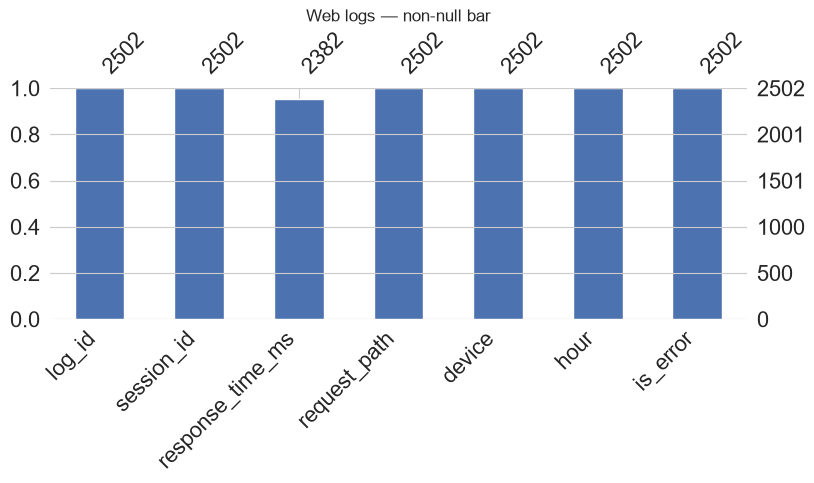

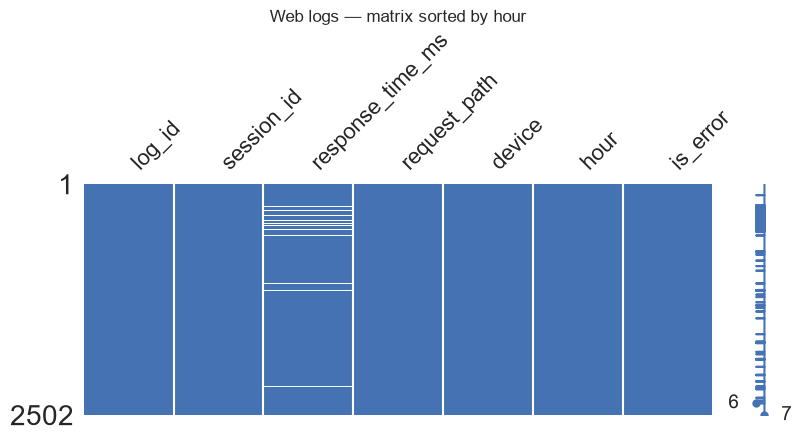

In [3]:
# 시나리오 1 — 결측 진단
print(logs_raw.isnull().sum())
print((logs_raw.isnull().mean() * 100).round(1))

msno.bar(logs_raw, color="#4C72B0", figsize=(9, 3))
plt.title("Web logs — non-null bar"); plt.show()

msno.matrix(logs_raw.sort_values("hour"), color=(0.27, 0.45, 0.70), figsize=(9, 3))
plt.title("Web logs — matrix sorted by hour"); plt.show()

In [4]:
# 시나리오 2 — 정제
logs_clean = logs_raw.drop_duplicates(subset="log_id").reset_index(drop=True)
# device 표기 통일 (대소문자 혼재)
device_map = {"mobile": "mobile", "Mobile": "mobile", "MOBILE": "mobile",
              "desktop": "desktop", "DESKTOP": "desktop"}
logs_clean["device"] = logs_clean["device"].map(device_map)
# hour 이상치 제거 (사실 0~23 외는 모두 이상)
logs_clean = logs_clean[logs_clean["hour"].between(0, 23)].copy()
# response_time_ms 결측 — 요청 경로별 중앙값으로 대체
medians = logs_clean.groupby("request_path")["response_time_ms"].median()
need = logs_clean["response_time_ms"].isna()
logs_clean.loc[need, "response_time_ms"] = logs_clean.loc[need, "request_path"].map(medians)
# response_time_ms 클리핑 (p99)
cap = logs_clean["response_time_ms"].quantile(0.99)
logs_clean.loc[logs_clean["response_time_ms"] > cap, "response_time_ms"] = cap

print("clean 모양:", logs_clean.shape, "| 결측 response_time_ms:", logs_clean["response_time_ms"].isna().sum())

clean 모양: (2499, 7) | 결측 response_time_ms: 0


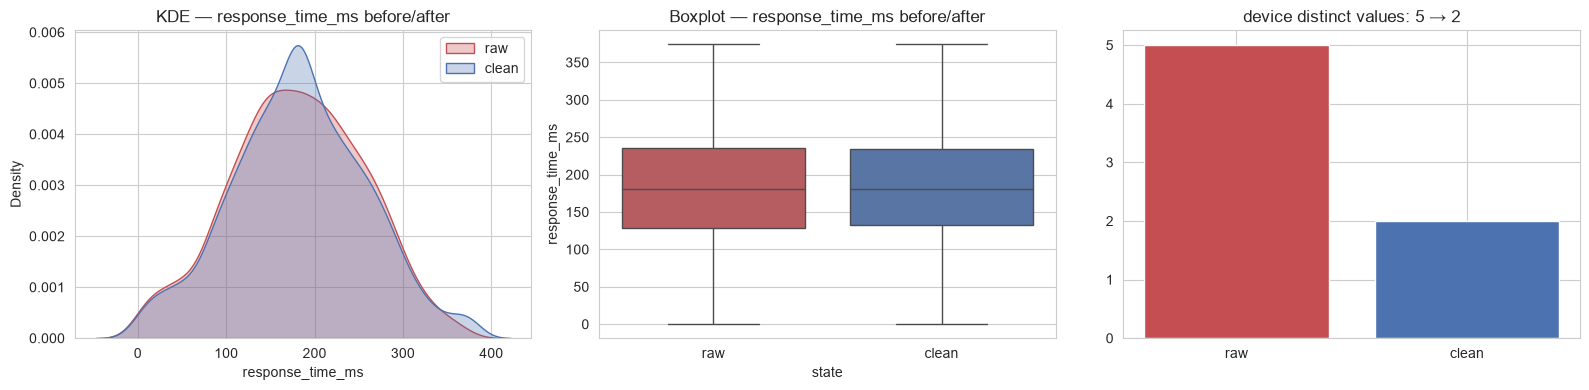

In [5]:
# 검증 — 전후 분포 비교 (3종 세트)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) KDE 겹쳐
raw_rt = logs_raw["response_time_ms"].dropna()
raw_rt = raw_rt[raw_rt <= cap]
sns.kdeplot(raw_rt, label="raw", color="#C44E52", fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(logs_clean["response_time_ms"], label="clean", color="#4C72B0", fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("KDE — response_time_ms before/after"); axes[0].legend()

# (b) 박스 side-by-side
long_rt = pd.concat([
    pd.DataFrame({"response_time_ms": raw_rt.values, "state": "raw"}),
    pd.DataFrame({"response_time_ms": logs_clean["response_time_ms"].values, "state": "clean"}),
])
sns.boxplot(data=long_rt, x="state", y="response_time_ms",
            order=["raw", "clean"], ax=axes[1], palette=["#C44E52", "#4C72B0"])
axes[1].set_title("Boxplot — response_time_ms before/after")

# (c) device 정제 검증
raw_dev_n = logs_raw["device"].nunique()
cln_dev_n = logs_clean["device"].nunique()
axes[2].bar(["raw", "clean"], [raw_dev_n, cln_dev_n], color=["#C44E52", "#4C72B0"])
axes[2].set_title(f"device distinct values: {raw_dev_n} → {cln_dev_n}")

plt.tight_layout(); plt.show()

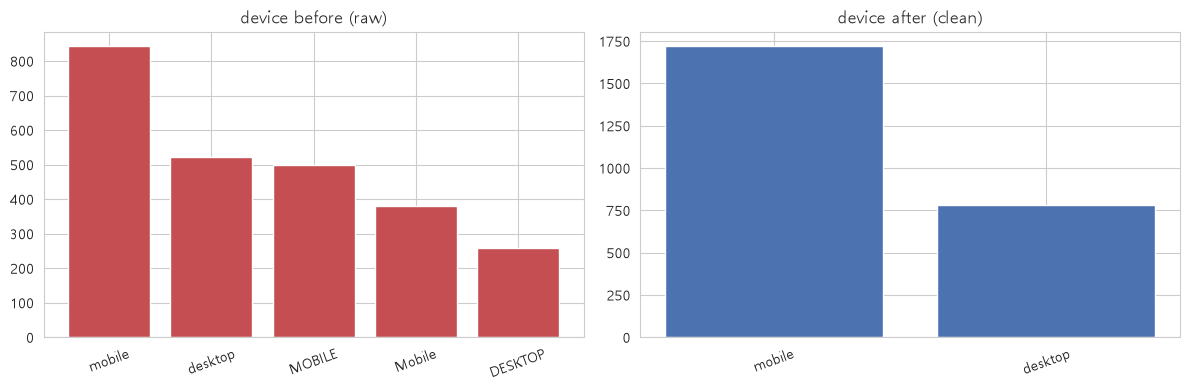

정제 전 device 비율(%):
device
mobile     33.7
desktop    20.9
MOBILE     20.0
Mobile     15.1
DESKTOP    10.3
Name: proportion, dtype: float64

정제 후 device 비율(%):
device
mobile     68.8
desktop    31.2
Name: proportion, dtype: float64


In [17]:
# (d) device 정제 전과후 비교
raw_dev_c = logs_raw["device"].value_counts()
cln_dev_c = logs_clean["device"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(raw_dev_c.index, raw_dev_c.values, color="#C44E52")
axes[0].set_title("device before (raw)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(cln_dev_c.index, cln_dev_c.values, color="#4C72B0")
axes[1].set_title("device after (clean)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

raw_dev_ratio = logs_raw["device"].value_counts(normalize=True).mul(100).round(1)
cln_dev_ratio = logs_clean["device"].value_counts(normalize=True).mul(100).round(1)

print("정제 전 device 비율(%):")
print(raw_dev_ratio)
print("\n정제 후 device 비율(%):")
print(cln_dev_ratio)


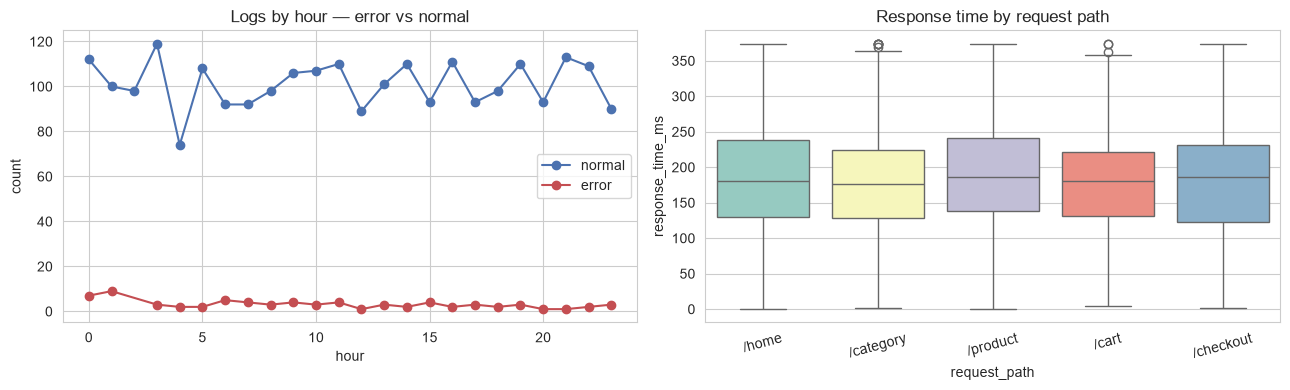

In [6]:
# 시나리오 3 — 탐색
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# (a) 시간대별 로그 수 — 에러 vs 정상 비교
hour_err = logs_clean.groupby(["hour", "is_error"]).size().reset_index(name="n")
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    part = hour_err[hour_err["is_error"] == label]
    axes[0].plot(part["hour"], part["n"], marker="o",
                 label="normal" if label == 0 else "error", color=color)
axes[0].set_title("Logs by hour — error vs normal")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("count"); axes[0].legend()

# (b) 요청 경로별 응답 시간 분포
sns.boxplot(data=logs_clean, x="request_path", y="response_time_ms",
            order=["/home", "/category", "/product", "/cart", "/checkout"],
            ax=axes[1], palette="Set3")
axes[1].set_title("Response time by request path")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

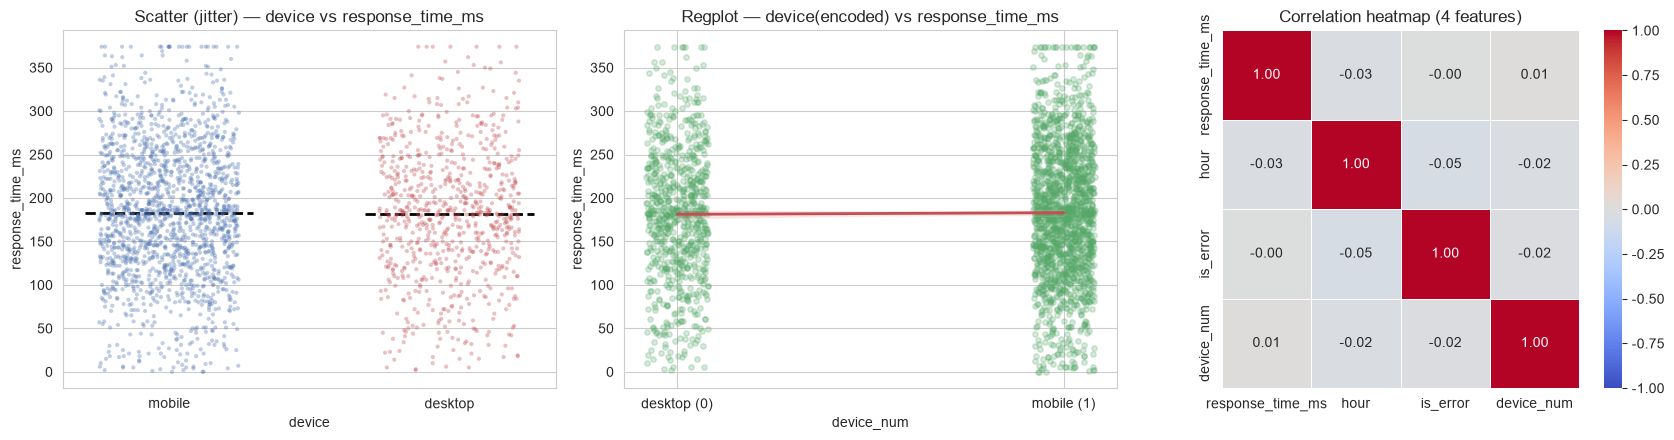

                  response_time_ms   hour  is_error  device_num
response_time_ms             1.000 -0.025    -0.002       0.011
hour                        -0.025  1.000    -0.048      -0.025
is_error                    -0.002 -0.048     1.000      -0.017
device_num                   0.011 -0.025    -0.017       1.000


In [ ]:
# ─────────────────────────────────────────────
# 시나리오 4 — device ↔ response_time_ms 관계 탐색 + 상관관계 히트맵
# ─────────────────────────────────────────────

# device를 이진 수치로 인코딩 (mobile=1, desktop=0) — 상관분석/regplot에 사용
logs_clean["device_num"] = (logs_clean["device"] == "mobile").astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) Scatter — device별 response_time 분포 (지터로 겹침 방지)
sns.stripplot(
    data=logs_clean, x="device", y="response_time_ms",
    order=["mobile", "desktop"],
    jitter=0.25, alpha=0.35, size=3,
    palette=["#4C72B0", "#C44E52"], ax=axes[0]
)
# 기기별 평균선도 같이 표시
means = logs_clean.groupby("device")["response_time_ms"].mean()
for i, dev in enumerate(["mobile", "desktop"]):
    axes[0].hlines(means[dev], i - 0.3, i + 0.3, color="black", linewidth=2, linestyle="--")
axes[0].set_title("Scatter (jitter) — device vs response_time_ms")

# (b) Regplot — device_num(0/1)을 x축으로, 지터를 줘서 추세선 확인
sns.regplot(
    data=logs_clean, x="device_num", y="response_time_ms",
    x_jitter=0.08, scatter_kws={"alpha": 0.25, "s": 15, "color": "#55A868"},
    line_kws={"color": "#C44E52", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["desktop (0)", "mobile (1)"])
axes[1].set_title("Regplot — device(encoded) vs response_time_ms")

# (c) 상관관계 히트맵 — 의미 있는 4개 컬럼 선별
#     response_time_ms : 응답시간(연속)
#     hour             : 시간대(0~23) — 트래픽 패턴과 응답시간 관계 확인용
#     is_error         : 에러 여부(0/1) — 에러와 응답시간 지연의 연관성 확인용
#     device_num       : 기기 종류(0/1) — 모바일/데스크톱 간 응답시간 차이 확인용
corr_cols = ["response_time_ms", "hour", "is_error", "device_num"]
corr = logs_clean[corr_cols].corr()

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=axes[2]
)
axes[2].set_title("Correlation heatmap (4 features)")

plt.tight_layout()
plt.show()

print(corr.round(3))

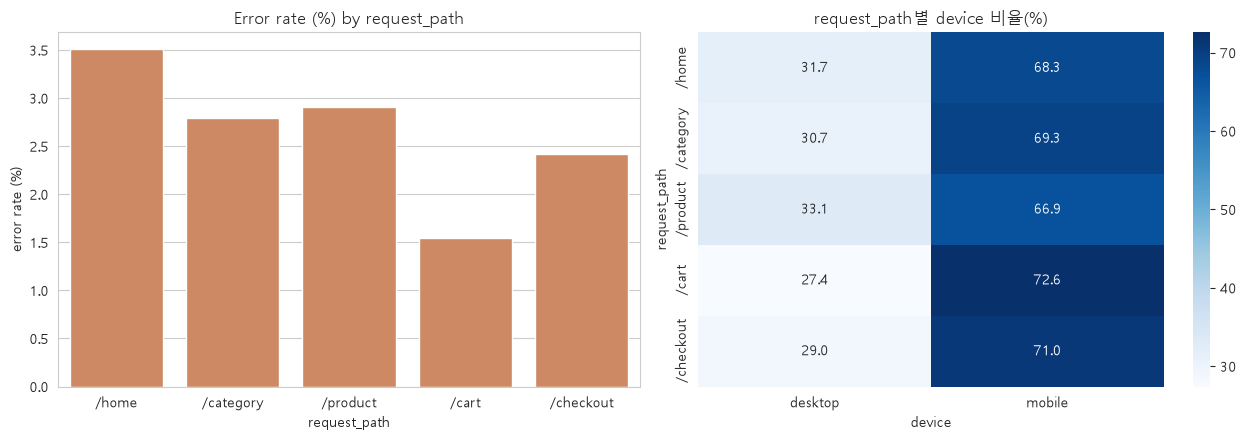

In [13]:
# ─────────────────────────────────────────────
# (b) 범주형 x 범주형 — request_path별 에러율, device별 경로 선호도
# ─────────────────────────────────────────────
# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows / Mac은 "AppleGothic", Linux는 "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

err_rate = logs_clean.groupby("request_path")["is_error"].mean().mul(100).reindex(
    ["/home", "/category", "/product", "/cart", "/checkout"])
sns.barplot(x=err_rate.index, y=err_rate.values, color="#DD8452", ax=axes[0])
axes[0].set_title("Error rate (%) by request_path")
axes[0].set_ylabel("error rate (%)")

# request_path x device 교차표 (비율, %) — 히트맵
cross = pd.crosstab(logs_clean["request_path"], logs_clean["device"], normalize="index").mul(100)
cross = cross.reindex(["/home", "/category", "/product", "/cart", "/checkout"])
sns.heatmap(cross, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("request_path별 device 비율(%)")

plt.tight_layout(); plt.show()

In [23]:
err_hour = (logs_clean.groupby(["hour", "is_error"]).size()
            .reset_index(name="count"))
err_hour["is_error"] = err_hour["is_error"].map({0: "normal", 1: "error"})

fig_plotly = px.bar(err_hour, x="hour", y="count", color="is_error",
                     barmode="group", title="Hourly logs — error vs normal",
                     color_discrete_map={"normal": "#4C72B0", "error": "#C44E52"})
fig_plotly.update_layout(width=900, height=420)
fig_plotly.show()

# HTML로 저장 (GitHub Pages에 올릴 파일)
fig_plotly.write_html("report_chart.html")

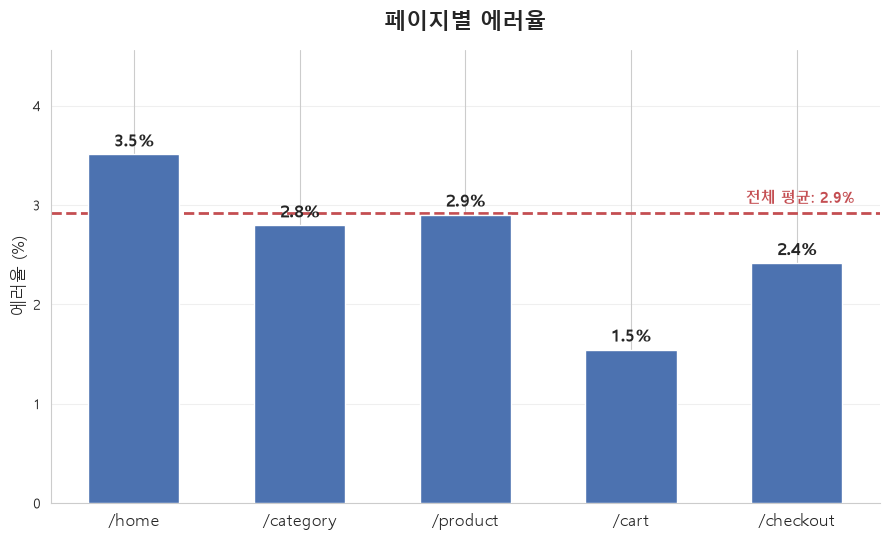

In [14]:
# 차트 한줄 요약
order = ["/home", "/category", "/product", "/cart", "/checkout"]
err_rate = logs_clean.groupby("request_path")["is_error"].mean().mul(100).reindex(order)
overall = logs_clean["is_error"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(err_rate.index, err_rate.values, color="#4C72B0", width=0.55, zorder=3)

# 전체 평균선
ax.axhline(overall, color="#C44E52", linestyle="--", linewidth=2, zorder=2)
ax.text(4.35, overall + 0.1, f"전체 평균: {overall:.1f}%",
        color="#C44E52", fontsize=11, fontweight="bold", ha="right")

# 막대 위에 값 표시
for bar, val in zip(bars, err_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.08, f"{val:.1f}%",
            ha="center", fontsize=12, fontweight="bold")

ax.set_title("페이지별 에러율", fontsize=16, fontweight="bold", pad=15)
ax.set_ylabel("에러율 (%)", fontsize=12)
ax.set_ylim(0, max(err_rate.values) * 1.3)
ax.tick_params(axis="x", labelsize=12)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("error_rate_simple.png", dpi=150, bbox_inches="tight")
plt.show()